In [ ]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [ ]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

# Functions

In [ ]:
def new_deltav(df_sp, metric):
    
    df6 = df_sp[(df_sp['ExperimentState'] != "Recovery") ]
    name = []
    if any(df6[metric].isnull()):
        name = df6[df6[metric].isnull()]['index'].tolist()
    dfsp_db = df6[~df6['index'].isin(name)]
           
    dfsp_db2 = dabest.load(data = dfsp_db, x = ["ExperimentState", "Type"], y = metric,  delta2 = True, experiment = "Type",
                            experiment_label = ['WT', 'Expt'], x1_level = ["Dark", "Full"], paired = "baseline", id_col="index" ) #if delta2 = dabest; deltaG = dabest_jck
    plot_data = dfsp_db2._plot_data
    idx = dfsp_db2.idx
    xvar = dfsp_db2._xvar
    yvar = dfsp_db2._yvar
    is_paired = dfsp_db2.is_paired
    id_col = dfsp_db2.id_col

    delta_plot_data_temp = plot_data.copy()
    delta_id_col = id_col
    delta_plot_data = delta_plot_data_temp[[xvar, yvar, delta_id_col]]

    final_deltas = pd.DataFrame()
    for i in idx:
        for j in i:
            if i.index(j) != 0:
                temp_df_exp = delta_plot_data[
                    delta_plot_data[xvar].str.contains(j)
                ].reset_index(drop=True)
                if is_paired == "baseline":
                    temp_df_cont = delta_plot_data[
                        delta_plot_data[xvar].str.contains(i[0])
                    ].reset_index(drop=True)
                elif is_paired == "sequential":
                    temp_df_cont = delta_plot_data[
                        delta_plot_data[xvar].str.contains(
                            i[i.index(j) - 1]
                        )
                    ].reset_index(drop=True)
                delta_df = temp_df_exp.copy()
                delta_df[yvar] = temp_df_exp[yvar] - temp_df_cont[yvar]
                final_deltas = pd.concat([final_deltas, delta_df])
    
    return final_deltas

def testingforPCA(n, df_sp, df_bsp, df_f, df_h, df_dispp, df_maxv, df_sim, alltgtmeandf_bout, alltgtnumberdf_bout, count):
    totaldf = pd.DataFrame()
       
    totaldf["Bout speed"] = new_deltav(df_bsp, "BSpeed")[new_deltav(df_bsp, "BSpeed")['TypeExperimentState']=="Full Expt"]['BSpeed'].reset_index(drop=True)
    totaldf["Speed"] = new_deltav(df_sp, "Velocity")[new_deltav(df_sp, "Velocity")['TypeExperimentState']=="Full Expt"]['Velocity'].reset_index(drop=True)
    totaldf["Fall #"] = new_deltav(df_f, "Fall")[new_deltav(df_f, "Fall")['TypeExperimentState']=="Full Expt"]['Fall'].reset_index(drop=True)
    totaldf["Height"] = new_deltav(df_h, "Y")[new_deltav(df_h, "Y")['TypeExperimentState']=="Full Expt"]['Y'].reset_index(drop=True)
    totaldf["Mean Bout"] = new_deltav(alltgtmeandf_bout, "Bouts")[new_deltav(alltgtmeandf_bout, "Bouts")['TypeExperimentState']=="Full Expt"]['Bouts'].reset_index(drop=True)
    totaldf["Bout #"] = new_deltav(alltgtnumberdf_bout, "Bouts")[new_deltav(alltgtnumberdf_bout, "Bouts")['TypeExperimentState']=="Full Expt"]['Bouts'].reset_index(drop=True)    
    totaldf["Max velocity"] = new_deltav(df_maxv, "maxvelocity")[new_deltav(df_maxv, "maxvelocity")['TypeExperimentState']=="Full Expt"]['maxvelocity'].reset_index(drop=True)
    totaldf["Avg Straightness index"] = new_deltav(df_sim, "averagestraightnessindex")[new_deltav(df_sim, "averagestraightnessindex")['TypeExperimentState']=="Full Expt"]['averagestraightnessindex'].reset_index(drop=True)
    totaldf["displacement between pause"] = new_deltav(df_dispp, "avgdisplacementbetweenpause")[new_deltav(df_dispp, "avgdisplacementbetweenpause")['TypeExperimentState']=="Full Expt"]['avgdisplacementbetweenpause'].reset_index(drop=True)
    totaldf['MBON'] = n
    totaldf = totaldf.set_index(['MBON'])
    totaldf['number'] = count

    return totaldf
    
    

# Code

In [ ]:
totaldf = pd.DataFrame()
count = 0
for n in lst:
    count +=1
    transgenic = n + " x " + responder
    filename = openPath + transgenic + ".csv"
    filenamewt = openPath + wt+"_"+ transgenic + ".csv"

    dfe=pd.read_csv(filename)
    dfw= pd.read_csv(filenamewt)

    exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
    wtdf = dfw.drop(dfw.columns[[0]],axis = 1)

    #adjust this depending on timeframe
    dfexpt = NLCLIMB.fivesecondrule(NLCLIMB.generation(exptdf, n))
    dfwt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wtdf, wt))

    df_sp = NLMATH.ospeed(dfwt, dfexpt).reset_index(drop=True)
    df_bsp = NLMATH.bspeed(NLMATH.boutspeed(dfexpt), NLMATH.boutspeed(dfwt)).reset_index(drop=True)
    df_f = NLMATH.fallingocc(dfexpt, dfwt).reset_index(drop=True)
    df_h = NLMATH.totalheight(dfexpt, dfwt).reset_index(drop=True)

    #newadditions
    df_dispp = pd.concat([NLMATH.displacementbetweenpauses(dfexpt, "Expt"), NLMATH.displacementbetweenpauses(dfwt, "WT")], axis = 0).reset_index(drop=False)
    df_maxv = pd.concat([NLMATH.maxvelocity(dfexpt, "Expt"), NLMATH.maxvelocity(dfwt, "WT")], axis = 0).reset_index(drop=False)
    df_sim = pd.concat([NLMATH.straightnessindexmeter(dfexpt, "Expt"), NLMATH.straightnessindexmeter(dfwt, "WT")], axis = 0).reset_index(drop=True)

    #pause and bouts
    wttotalmeanevent, wttotalnumberevent = NLMATH.pausecomp(dfwt, wt)
    expttotalmeanevent, expttotalnumberevent = NLMATH.pausecomp(dfexpt, n)
        
    #alltgtmeandf_pause = pd.concat([NLMATH.pausenumber(wttotalmeanevent, n, "Pauses"), NLMATH.pausenumber(expttotalmeanevent, n, "Pauses")], axis = 0).reset_index(drop=True)
    alltgtmeandf_bout = pd.concat([NLMATH.pausenumber(wttotalmeanevent, n, "Bouts"), NLMATH.pausenumber(expttotalmeanevent, n, "Bouts")], axis = 0).reset_index(drop=True)

    #alltgtnumberdf_pause = pd.concat([NLMATH.pausenumber(wttotalnumberevent, n, "Pauses"), NLMATH.pausenumber(expttotalnumberevent, n, "Pauses")], axis = 0).reset_index(drop=True)
    alltgtnumberdf_bout = pd.concat([NLMATH.pausenumber(wttotalnumberevent, n, "Bouts"), NLMATH.pausenumber(expttotalnumberevent, n, "Bouts")], axis = 0).reset_index(drop=True)
    
    alltgtnumberdf_bout['genre'] = alltgtnumberdf_bout['ExperimentState'] + " " + alltgtnumberdf_bout['Type']
    alltgtmeandf_bout['genre'] = alltgtnumberdf_bout['ExperimentState'] + " " + alltgtnumberdf_bout['Type']
    
    totaldf = pd.concat([totaldf, testingforPCA(n, df_sp, df_bsp, df_f, df_h, df_dispp, df_maxv, df_sim, alltgtmeandf_bout, alltgtnumberdf_bout, count)])

In [ ]:
totaldf.to_csv(openPath + "Compilation with delta\\" + date + "pairedplotdeltawithmetrics.csv")

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

totaldf1 = totaldf.dropna()
pca = PCA()
components = pca.fit_transform(totaldf1[totaldf1.columns[:-1]])
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

fig = px.scatter_matrix(
    components,
    labels=labels,
    dimensions=range(4),
    color=totaldf1["number"], width = 800, height = 800
)
fig.update_traces(diagonal_visible=False, marker =dict(size = 3) )
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_california_housing



pca = PCA(n_components=9)
components = pca.fit_transform(totaldf1[totaldf1.columns[:-1]])

total_var = pca.explained_variance_ratio_.sum() * 100

labels = {str(i): f"PC {i+1}" for i in range(9)}
labels['color'] = 'Median Price'

fig = px.scatter_matrix(
    components,
    color=totaldf1["number"],
    dimensions=range(9),
    labels=labels,
    title=f'Total Explained Variance: {total_var:.2f}%', width = 1200, height = 1200
)
fig.update_traces(diagonal_visible=False, marker =dict(size = 3))
fig.show()

Text(0.5, 1.0, 'n_components vs. Explained Variance Ratio')

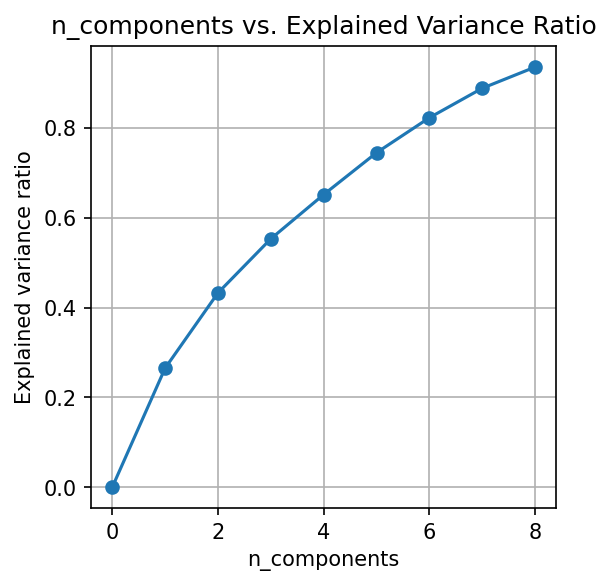

In [ ]:
#PCA covariance explained
totaldf1 = totaldf.dropna()

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(totaldf1)

nums = np.arange(9)
var_ratio = []
for num in nums:
  pca = PCA(n_components=num)
  pca.fit(scaled_df)
  var_ratio.append(np.sum(pca.explained_variance_ratio_))
  
plt.figure(figsize=(4,4),dpi=150)
plt.grid()
plt.plot(nums,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.title('n_components vs. Explained Variance Ratio')